In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

In [2]:
from pathlib import Path
save_dir = Path("../pics/circle_node/zero_aug_T=1/eigedirections")
save_dir.mkdir(parents=True, exist_ok=True)

import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import NN_LyapExp
from src.networks import NeuralODEClassifier, NeuralODE_Truncated, NeuralODE_Full, init_weights
from src.utils import lyapunov_autograd, train

In [3]:
from matplotlib.colors import LinearSegmentedColormap

tf_playground = LinearSegmentedColormap.from_list(
    "tf_playground",
    [
        "#f4a261", # orange
        "#ffffff", # white
        "#2a9df4"  # blue
    ]
)

In [4]:
data = np.load("circle_dataset_eps0p01.npz")

X_train = data["X"]
y_train = data["y"]
# epsilon = data["epsilon"]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_standardized = (X_train - mean)/std

In [5]:
data = np.load("circle_dataset_eps0p01_val.npz")

X_val = data["X"]
y_val = data["y"]

X_val_standardized = (X_val - mean)/std

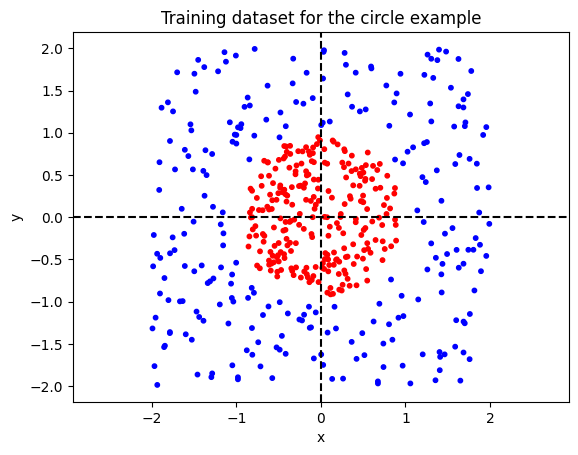

In [6]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="bwr_r", s=10)
plt.axvline(0.0, color="k", linestyle="--")
plt.axhline(0.0, color="k", linestyle="--")
plt.axis("equal")
plt.ylabel("y")
plt.xlabel("x")
plt.title("Training dataset for the circle example")
plt.show()

In [7]:
print(len(y_train))

500


In [8]:
X_train_standardized = torch.tensor(X_train_standardized, dtype=torch.float32).float()
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).float()  # add dimension if needed

X_val_standardized = torch.tensor(X_val_standardized, dtype=torch.float32).float()
y_val = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_standardized, y_train)
val_ds = TensorDataset(X_val_standardized, y_val)

train_dataloader = DataLoader(train_ds, batch_size=64)
val_dataloader = DataLoader(val_ds, batch_size=64)

In [9]:
M = 10
seeds = [45]
# seeds = [11]

radii = np.linspace(0.2, 1.8, 40)
loss_fn = nn.MSELoss()

In [10]:
def point_generator(radius, n=32):
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

In [11]:
T = 1.0
all_LEs = []
all_LEs_min = []
for seed in seeds:
    torch.manual_seed(seed)

    neural_ode = NeuralODEClassifier(input_dim=2, hidden_dim=3)
    neural_ode.apply(lambda m: init_weights(m, init_type="gaussian", gain=0.9))

    train(neural_ode, train_dataloader, val_dataloader, loss_fn, acc_target=0.95, seed=seed, epochs=5000)

    # run_LEs = []
    # run_LEs_min = []

    # neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

#     for r in radii:
#         X = point_generator(r, n=32)
#         X = torch.tensor(X, dtype=torch.float32)

#         le_r, le_rmin = lyapunov_autograd(X[0, :], X[1, :], neural_ode_trunc, mean, std, T=T)

#         run_LEs.append(le_r.mean())
#         run_LEs_min.append(le_rmin.mean())

#     all_LEs.append(run_LEs)
#     all_LEs_min.append(run_LEs_min)

# all_LEs = np.array(all_LEs)
# all_LEs_min = np.array(all_LEs_min) 

Epoch 0 | Train Loss 3.967162 | Validation Accuracy 0.196000
Epoch 20 | Train Loss 1.784205 | Validation Accuracy 0.196000
Epoch 40 | Train Loss 1.268816 | Validation Accuracy 0.172000
Epoch 60 | Train Loss 1.072523 | Validation Accuracy 0.128000
Epoch 80 | Train Loss 0.970741 | Validation Accuracy 0.112000
Epoch 100 | Train Loss 0.905833 | Validation Accuracy 0.100000
Epoch 120 | Train Loss 0.859088 | Validation Accuracy 0.088000
Epoch 140 | Train Loss 0.822546 | Validation Accuracy 0.088000
Epoch 160 | Train Loss 0.792645 | Validation Accuracy 0.080000
Epoch 180 | Train Loss 0.768125 | Validation Accuracy 0.080000
Epoch 200 | Train Loss 0.747278 | Validation Accuracy 0.088000
Epoch 220 | Train Loss 0.729557 | Validation Accuracy 0.088000
Epoch 240 | Train Loss 0.713959 | Validation Accuracy 0.104000
Epoch 260 | Train Loss 0.700019 | Validation Accuracy 0.112000
Epoch 280 | Train Loss 0.687252 | Validation Accuracy 0.136000
Epoch 300 | Train Loss 0.675418 | Validation Accuracy 0.14000

In [12]:
x_vals = np.linspace(-2, 2, 50)  # Make it 50 to improve time it takes
y_vals = np.linspace(-2, 2, 50)

t0 = 0.0
# t1_list = np.linspace(0.01, 1.0, 20)
t1 = 1.0

In [13]:
# lyap_grid_list = []
# lyap_grid_min_list = []
# for t1 in t1_list:
lyap_grid_2d = np.zeros((len(x_vals), len(y_vals)))
lyap_grid_min_2d = np.zeros_like(lyap_grid_2d)

max_dirs_2d = np.zeros((len(y_vals), len(x_vals), 2))
min_dirs_2d = np.zeros((len(y_vals), len(x_vals), 2))

neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        # Create 1×2 input
        x0 = torch.tensor([[x, y]], dtype=torch.float32)

        # Standardize using your saved statistics
        x0 = ((x0 - mean) / std).float()

        # Compute Jacobian
        J = nn_lyap.jacobian_flow(x0, t0=t0, t1=t1)

        # Singular values
        U, svals, Vh = torch.linalg.svd(J)

        # Largest Lyapunov proxy
        lyap_grid_2d[j, i] = (1.0/(t1-t0)) * torch.log(svals.max()).item()
        lyap_grid_min_2d[j, i] =(1.0/(t1-t0)) * torch.log(svals.min()).item()

        # Right singular vectors
        V = Vh.t()

        # Largest stretching direction  
        max_dirs_2d[j, i] = V[:, 0].detach().cpu().numpy()

        # Smallest stretching direction
        min_dirs_2d[j, i] = V[:, 1].detach().cpu().numpy()

    # lyap_grid_list.append(lyap_grid)
    # lyap_grid_min_list.append(lyap_grid_min)  

In [14]:
print(x0.shape)

y = neural_ode_trunc(x0, t0=t0, t1=t1)
print(y.shape)

J = nn_lyap.jacobian_flow(x0, t0=t0, t1=t1)
print(J.shape)

torch.Size([1, 2])
torch.Size([1, 3])
torch.Size([3, 2])


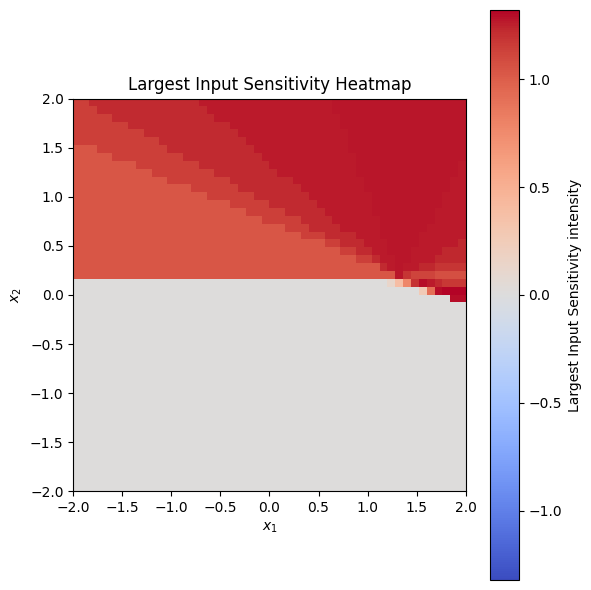

In [15]:
X, Y = np.meshgrid(x_vals, y_vals)

fig, ax = plt.subplots(figsize=(6,6))

v_max = np.max(np.abs(lyap_grid_2d))
v_min = np.max(np.abs(lyap_grid_min_2d))
v = max(v_max, v_min)

im = ax.imshow(
    lyap_grid_2d,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',
    vmin=-v,
    vmax=v
)

# skip = 4

# ax.quiver(
#     X[::skip, ::skip],
#     Y[::skip, ::skip],

#     max_dirs_2d[::skip, ::skip, 0],
#     max_dirs_2d[::skip, ::skip, 1],

#     color='black',
#     scale=20,
#     width=0.003
# )

fig.colorbar(im, ax=ax, label="Largest Input Sensitivity intensity")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Largest Input Sensitivity Heatmap")

fig.tight_layout()

fig.savefig(save_dir / "0base_relu_1ftle_45", dpi=300, bbox_inches='tight')

plt.show()

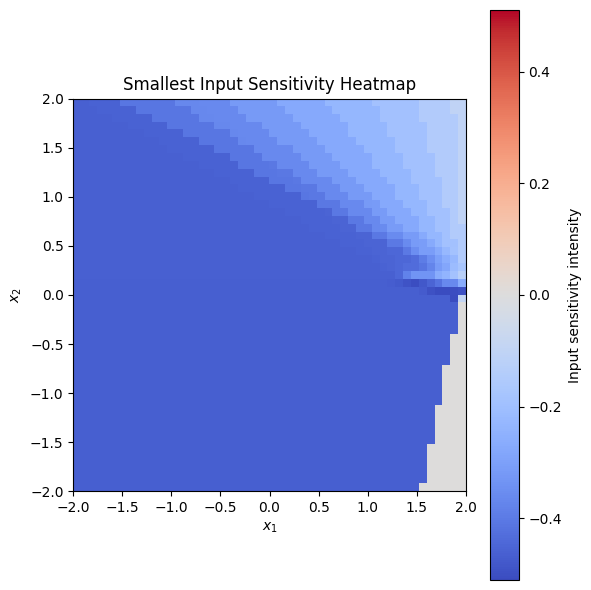

In [16]:
fig, ax = plt.subplots(figsize=(6,6))


im = ax.imshow(
    lyap_grid_min_2d,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',
    vmin=-v_min,
    vmax=v_min
)

# ax.quiver(
#     X[::skip, ::skip],
#     Y[::skip, ::skip],

#     min_dirs_2d[::skip, ::skip, 0],
#     min_dirs_2d[::skip, ::skip, 1],

#     color='red',
#     scale=20,
#     width=0.003
# )

fig.colorbar(im, ax=ax, label="Input sensitivity intensity")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Smallest Input Sensitivity Heatmap")

fig.tight_layout()

fig.savefig(save_dir / "0base_relu_2ftle_45.png", dpi=300, bbox_inches='tight')

plt.show()

In [17]:
X, Y = np.meshgrid(x_vals, y_vals)

points = np.stack([X.ravel(), Y.ravel()], axis=1)
points_t = torch.tensor(points, dtype=torch.float32)

points_t = ((points_t - mean) / std).float()

neural_ode.eval()
with torch.no_grad():
    preds = neural_ode(points_t).cpu().numpy()

Z = preds.reshape(len(x_vals), len(y_vals))

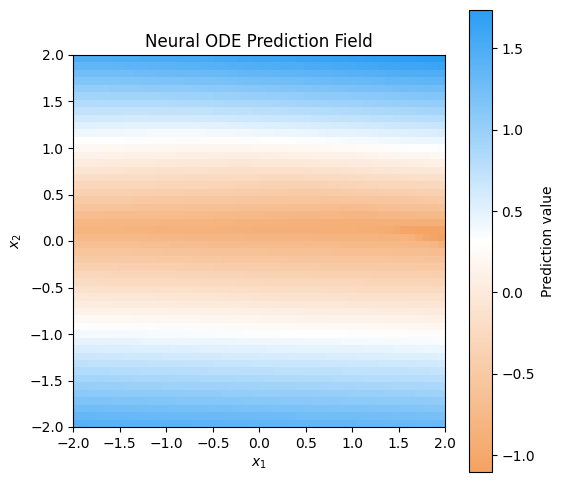

In [18]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    Z,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap=tf_playground,
)

fig.colorbar(im, ax=ax, label="Prediction value")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Neural ODE Prediction Field")


fig.savefig(save_dir / "0base_relu_pred_45.png", dpi=300)

plt.show()

In [19]:
Y_true = np.where(X**2 + Y**2 < 1, -1, 1)

Z = preds.reshape(len(y_vals), len(x_vals))
Y_pred = np.where(Z < 0, -1, 1)

accuracy = (Y_pred.flatten() == Y_true.flatten()).mean()
print("Accuracy:", accuracy)

Accuracy: 0.7664


In [20]:
t_eval = torch.linspace(0, 1, 100)

with torch.no_grad():
    traj = neural_ode.get_hidden_trajectory(points_t, t_eval) # Shape time_steps, num_points, 3

In [21]:
x_colors = points_t[:, 0]
y_colors = points_t[:, 1]

labels = torch.where((x_colors**2 + y_colors**2)<=1, -1, 1)

colors = torch.zeros((points_t.shape[0], 3)) # RGB

# Red if the point is inside the circle
colors[labels == -1] = torch.tensor([1.0, 0.0, 0.0])

# Blue if the point is outside the circle
colors[labels == 1] = torch.tensor([0.0, 0.0, 1.0])
colors_np = colors.numpy()

Saved GIF: xavier_normal_hidden_flow_42.gif


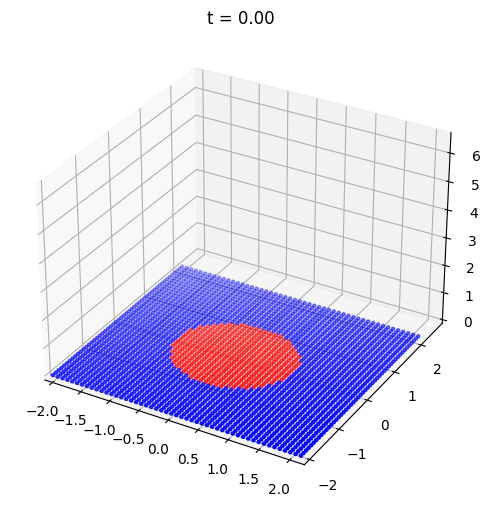

In [22]:
from matplotlib.animation import FuncAnimation
# matplotlib.use("Agg")

T, N, _ = traj.shape
traj_np = traj.cpu().numpy()

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Initial scatter
scatter = ax.scatter(traj_np[0,:,0], traj_np[0,:,1], traj_np[0,:,2], c=colors_np, s=5)

ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())
# ax.set_title("Neural ODE flow in hidden space"

def update(frame):
    scatter._offsets3d = (
        traj_np[frame,:,0],
        traj_np[frame,:,1],
        traj_np[frame,:,2],
    )
    ax.set_title(f"t = {1*frame/(T-1):.2f}")
    return scatter,

anim = FuncAnimation(fig, update, frames=T, interval=80)

anim.save(f"{save_dir}/0base_relu_hidden_flow_45.gif", writer="pillow", fps=15)
print("Saved GIF: xavier_normal_hidden_flow_42.gif")

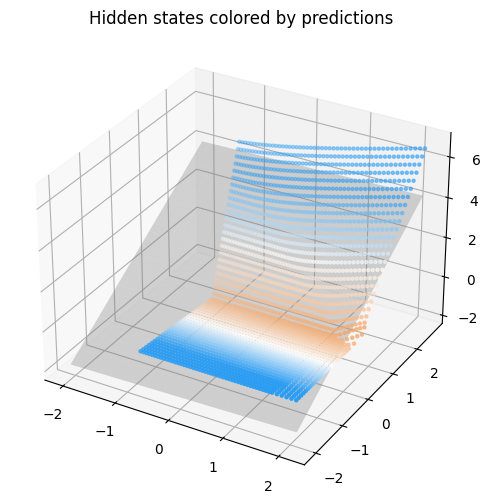

In [23]:
# Z is shape (len(x_vals), len(y_vals)), e.g., (100,100)
Z_flat = Z.ravel()  # shape (10000,)

# Normalize predictions to [0,1] if needed
Z_norm = (Z_flat + 1) / 2  # assuming predictions in [-1,1]

# Map to colors
colors_pred = tf_playground(Z_norm)  # shape (10000, 4) 
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_pred, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()


In [24]:
fig.savefig(f"{save_dir}/0base_relu_final_frame_pred_45.png")

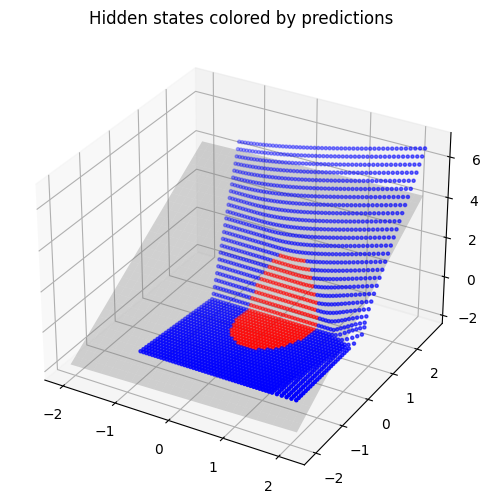

In [25]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_np, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()

In [26]:
fig.savefig(f"{save_dir}/0base_relu_final_frame_true_45.png")

In [27]:
print(traj.std(dim=1))

tensor([[1.2311, 1.2348, 0.0000],
        [1.2255, 1.2390, 0.0127],
        [1.2200, 1.2430, 0.0255],
        [1.2145, 1.2470, 0.0386],
        [1.2091, 1.2508, 0.0518],
        [1.2037, 1.2544, 0.0651],
        [1.1983, 1.2580, 0.0787],
        [1.1929, 1.2614, 0.0923],
        [1.1875, 1.2646, 0.1062],
        [1.1822, 1.2677, 0.1202],
        [1.1769, 1.2707, 0.1344],
        [1.1716, 1.2735, 0.1487],
        [1.1664, 1.2762, 0.1632],
        [1.1611, 1.2788, 0.1778],
        [1.1559, 1.2812, 0.1926],
        [1.1508, 1.2834, 0.2075],
        [1.1456, 1.2855, 0.2225],
        [1.1405, 1.2875, 0.2377],
        [1.1354, 1.2893, 0.2531],
        [1.1303, 1.2910, 0.2685],
        [1.1252, 1.2925, 0.2841],
        [1.1202, 1.2939, 0.2998],
        [1.1152, 1.2951, 0.3157],
        [1.1102, 1.2963, 0.3316],
        [1.1052, 1.2973, 0.3477],
        [1.1003, 1.2981, 0.3639],
        [1.0954, 1.2989, 0.3802],
        [1.0905, 1.2995, 0.3966],
        [1.0856, 1.3001, 0.4132],
        [1.080